#### Importamos todas las libreriras que vamos a utilizar

In [193]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
#import requests

### Acerca de: Inside Airbnb es un proyecto impulsado por una misión que proporciona datos y defensa sobre el impacto de Airbnb en las comunidades residenciales.Trabajamos hacia una visión en la que las comunidades estén empoderadas con datos e información para comprender, decidir y controlar el papel del alquiler de viviendas residenciales a turistas.

Generamos el dataset Airbnb en Buenos Aires

In [194]:
df = pd.read_csv("C:/Users/Gonzalo Rodriguez/OneDrive/Documentos/Especializacion en IA -CEIA/Analisis de datos/TP/listings.csv")

Primera idea de que tiene el data set

In [195]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,42610838,"Puerto Madero a 3 cuadras, centro, bello , tea...",224049389,1469188629918707060,Gabriela,NaN,San Nicolas,-34.599976,-58.374195,Entire home/apt,NaN,7.0,0,NaN,NaN,2,244,0,NaN
1,1305876403852901802,Apart estudio en Microcentro,25649070,1465347917068117288,Federico,NaN,San Nicolas,-34.600382,-58.372692,Entire home/apt,NaN,2.0,1,2025-01-18,0.08,1,307,0,NaN
2,1542233033640525302,"Departamento en Buenos Aires, abasto shopping",153014015,1468500000533080859,Marco,NaN,Balvanera,-34.603295,-58.409527,Entire home/apt,NaN,7.0,0,NaN,NaN,1,326,0,NaN
3,1004530078359434134,Departamento en Recoleta,1409800,1462517876404348407,Marian,NaN,Balvanera,-34.599230,-58.407060,Entire home/apt,NaN,1.0,22,2025-12-07,0.80,39,365,3,NaN
4,800145927121871422,Coqueto para 4 personas,467965425,1470109782901816721,Maria Del Carmen,NaN,Almagro,-34.599767,-58.426499,Entire home/apt,NaN,1.0,0,NaN,NaN,2,365,0,NaN


#### Hacemos un shape y vemos que el data set tiene 22877 observaciones distribuida en 15 variables

In [196]:
df.shape

(27348, 19)

Informacion de las variables

In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27348 non-null  int64  
 1   name                            27348 non-null  str    
 2   host_id                         27348 non-null  int64  
 3   host_profile_id                 27348 non-null  int64  
 4   host_name                       27348 non-null  str    
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   27348 non-null  str    
 7   latitude                        27348 non-null  float64
 8   longitude                       27348 non-null  float64
 9   room_type                       27348 non-null  str    
 10  price                           0 non-null      float64
 11  minimum_nights                  27242 non-null  float64
 12  number_of_reviews               27348 non-n

Variables numericas

In [198]:
df.describe()

,id,host_id,host_profile_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.734800e+04,2.734800e+04,2.734800e+04,0.0,27348.000000,27348.000000,0.0,27242.000000,27348.000000,24045.000000,27348.000000,27348.000000,27348.000000
mean,8.556780e+17,2.372763e+08,1.469908e+18,NaN,-34.592076,-58.416340,NaN,4.748770,38.127176,1.464834,12.394398,239.999963,12.231827
std,5.477969e+17,2.233505e+08,1.840941e+16,NaN,0.017927,0.029938,NaN,16.434273,56.082583,1.559983,27.895493,113.614547,17.429681
min,1.150800e+04,1.342600e+04,1.462507e+18,NaN,-34.690056,-58.530890,NaN,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,5.626035e+17,3.427341e+07,1.462899e+18,NaN,-34.603202,-58.435973,NaN,1.000000,4.000000,0.390000,1.000000,151.000000,1.000000
50%,9.886724e+17,1.587017e+08,1.466922e+18,NaN,-34.591370,-58.418325,NaN,2.000000,17.000000,1.000000,2.000000,269.000000,5.000000
75%,1.293344e+18,4.600936e+08,1.469954e+18,NaN,-34.581471,-58.391140,NaN,3.000000,51.000000,2.030000,9.000000,344.000000,17.000000
max,1.605545e+18,7.420151e+08,1.605075e+18,NaN,-34.535630,-58.355403,NaN,730.000000,1044.000000,28.690000,188.000000,365.000000,329.000000


Variables Numericas: Tenemos 13 variables numericas. 

| Variable | Traducción | Descripción | Tipo | Observación |
|---|---|---|---|---|
| `id` | Identificador del alojamiento | ID único de cada publicación | Discreta | Identificador, sin sentido aritmético |
| `host_id` | Identificador del anfitrión | ID único del anfitrión | Discreta | Identificador, sin sentido aritmético |
| `host_profile_id` | Identificador de perfil del anfitrión | ID del perfil público del anfitrión | Discreta | Identificador, sin sentido aritmético |
| `neighbourhood_group` | Grupo de barrio | Zona o distrito donde se ubica el alojamiento | Discreta | Columna vacía en el dataset |
| `latitude` | Latitud | Coordenada geográfica norte-sur del alojamiento | Continua | Coordenada geoespacial |
| `longitude` | Longitud | Coordenada geográfica este-oeste del alojamiento | Continua | Coordenada geoespacial |
| `price` | Precio por noche | Precio en moneda local por noche | Continua | Columna vacía en el dataset |
| `minimum_nights` | Noches mínimas | Cantidad mínima de noches para reservar | Discreta | Toma valores enteros positivos |
| `number_of_reviews` | Número de reseñas | Total acumulado de reseñas del alojamiento | Discreta | Toma valores enteros positivos |
| `reviews_per_month` | Reseñas por mes | Promedio mensual de reseñas recibidas | Continua | Puede tomar cualquier valor decimal |
| `calculated_host_listings_count` | Publicaciones del anfitrión | Número de alojamientos publicados por el anfitrión | Discreta | Toma valores enteros positivos |
| `availability_365` | Disponibilidad anual | Días disponibles en los próximos 365 días | Discreta | Valores enteros entre 0 y 365 |
| `number_of_reviews_ltm` | Reseñas últimos 12 meses | Cantidad de reseñas recibidas en el último año | Discreta | Toma valores enteros positivos |

Ahora veamos las variables categoricas

In [208]:
df.describe(include=['str'])

,name,host_name,neighbourhood,room_type,license
count,27348,27348,27348,27348,461
unique,25866,3841,48,4,424
top,Departamento en Buenos Aires,Federico,Palermo,Entire home/apt,IF-2025-23263934-GCABA-DGDTU
freq,69,465,8963,24890,8


tenemos un total de 5 variables

| Variable | Traducción | Descripción | Tipo | Observación |
|---|---|---|---|---|
| `name` | Nombre del alojamiento | Título de la publicación en Airbnb | Nominal | Texto libre, alta cardinalidad |
| `host_name` | Nombre del anfitrión | Nombre público del anfitrión | Nominal | Texto libre, alta cardinalidad |
| `neighbourhood` | Barrio | Barrio donde se ubica el alojamiento | Nominal | Cantidad acotada de valores únicos |
| `room_type` | Tipo de habitación | Tipo de alojamiento ofrecido (casa completa, habitación privada, etc.) | Nominal | Pocos valores únicos |
| `last_review` | Última reseña | Fecha de la última reseña recibida | — | Variable temporal, no categórica pura |

Vamos a modificar la variable 'last_review' a variable numerica, ya que es una variable que se utiliza para medir tiempo transcurrido

In [201]:
df['last_review'] = pd.to_datetime(df['last_review'])
df['last_review_num'] = df['last_review'].astype(int)

In [202]:
df.describe()

,id,host_id,host_profile_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review_num
count,2.734800e+04,2.734800e+04,2.734800e+04,0.0,27348.000000,27348.000000,0.0,27242.000000,27348.000000,24045,24045.000000,27348.000000,27348.000000,27348.000000,2.734800e+04
mean,8.556780e+17,2.372763e+08,1.469908e+18,NaN,-34.592076,-58.416340,NaN,4.748770,38.127176,2025-08-01 16:06:02.919526,1.464834,12.394398,239.999963,12.231827,-1.112426e+18
min,1.150800e+04,1.342600e+04,1.462507e+18,NaN,-34.690056,-58.530890,NaN,1.000000,0.000000,2013-01-06 00:00:00,0.010000,1.000000,0.000000,0.000000,-9.223372e+18
25%,5.626035e+17,3.427341e+07,1.462899e+18,NaN,-34.603202,-58.435973,NaN,1.000000,4.000000,2025-10-09 00:00:00,0.390000,1.000000,151.000000,1.000000,1.742774e+15
50%,9.886724e+17,1.587017e+08,1.466922e+18,NaN,-34.591370,-58.418325,NaN,2.000000,17.000000,2025-12-20 00:00:00,1.000000,2.000000,269.000000,5.000000,1.765498e+15
75%,1.293344e+18,4.600936e+08,1.469954e+18,NaN,-34.581471,-58.391140,NaN,3.000000,51.000000,2026-01-08 00:00:00,2.030000,9.000000,344.000000,17.000000,1.767744e+15
max,1.605545e+18,7.420151e+08,1.605075e+18,NaN,-34.535630,-58.355403,NaN,730.000000,1044.000000,2026-01-25 00:00:00,28.690000,188.000000,365.000000,329.000000,1.769299e+15
std,5.477969e+17,2.233505e+08,1.840941e+16,NaN,0.017927,0.029938,NaN,16.434273,56.082583,NaN,1.559983,27.895493,113.614547,17.429681,3.006224e+18


Vemos como 'last_review' ya aparece en la descripcion de variables numericas

Porcentaje de valores nulos

In [203]:
df.isna().mean() * 100

id                                  0.000000
name                                0.000000
host_id                             0.000000
host_profile_id                     0.000000
host_name                           0.000000
neighbourhood_group               100.000000
neighbourhood                       0.000000
latitude                            0.000000
longitude                           0.000000
room_type                           0.000000
price                             100.000000
minimum_nights                      0.387597
number_of_reviews                   0.000000
last_review                        12.077666
reviews_per_month                  12.077666
calculated_host_listings_count      0.000000
availability_365                    0.000000
number_of_reviews_ltm               0.000000
license                            98.314319
last_review_num                     0.000000
dtype: float64

Vemos el porcentaje de nulos en cada una de las variables. Se observan en principio que las variables **'price'** y **'neighbourhood_group'** ya que estan completamente vacias. Y habra que revisar la variable **'license'** que esta con el 98% de valores faltntes, casi vacia de datos.

### Vamos a realizar graficos para observar comportamientos de las variables

Realicemos un pair plot de todas las variables numericas para ver su distribucion y realacion

In [218]:
cols = df.select_dtypes(include=['number']).columns.tolist()
print(cols)

['id', 'host_id', 'host_profile_id', 'neighbourhood_group', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'last_review_num']


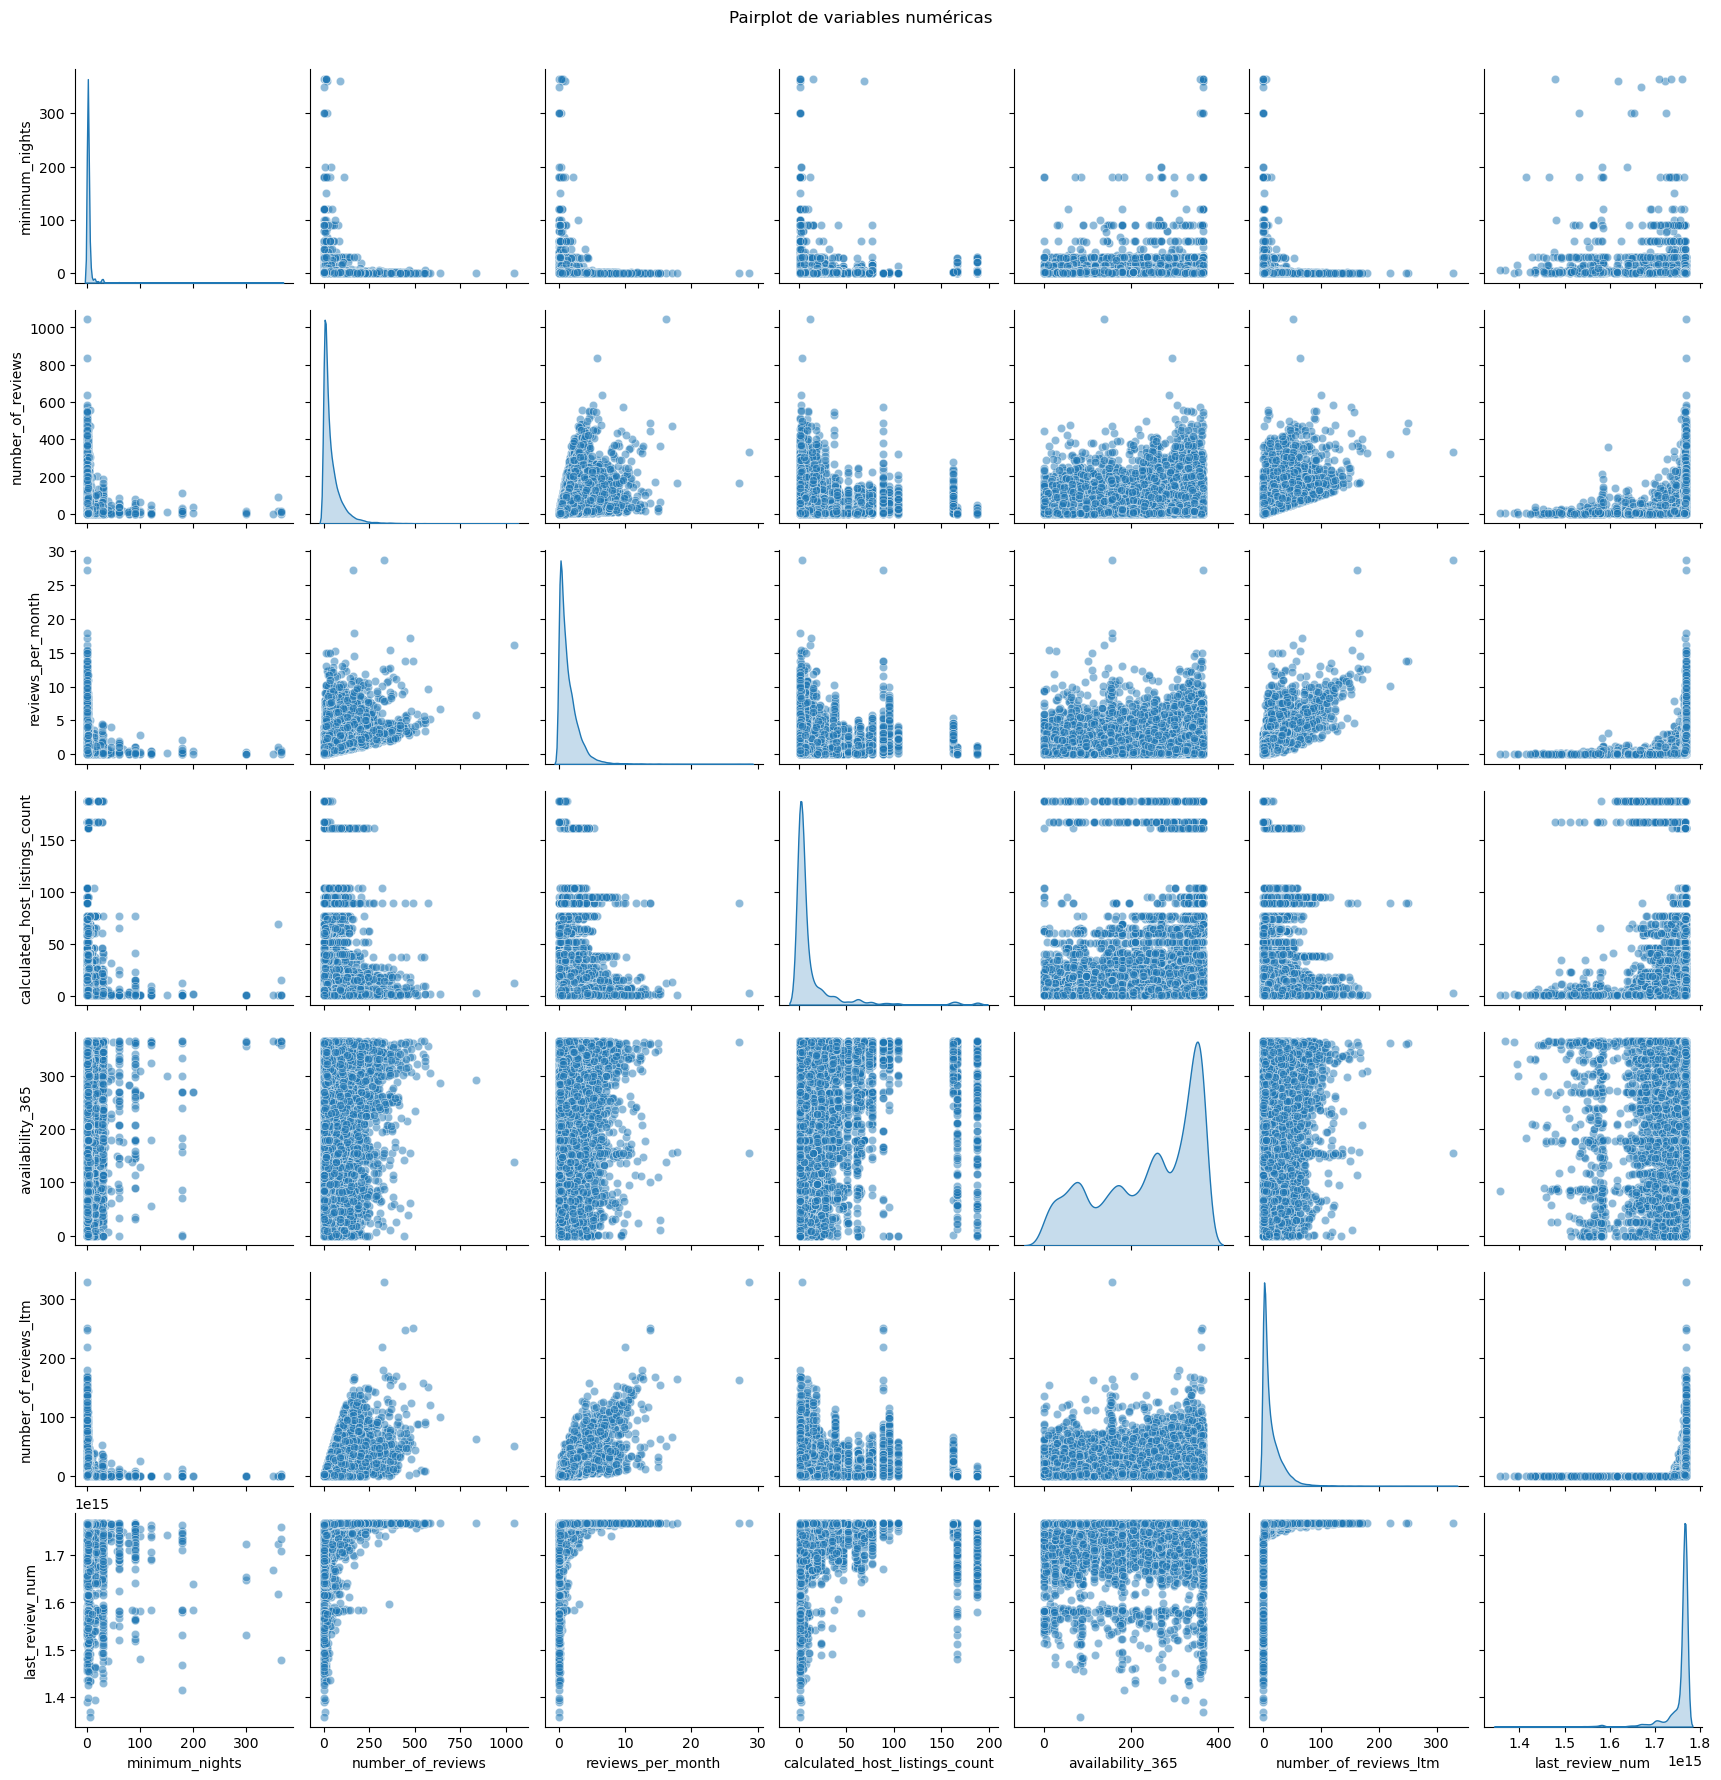

In [223]:
cols = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'last_review_num']

sns.pairplot(df[cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

Se observa en las variable **Price**, **numer_of_reviews** y **number_of_nights** que tienen una distribucion con un cola muy larga hacia la derecha lo que dificulta observar algun patron. Por ejemplo la variable number of night esta la mayoria en un valor menor a 30.

Slice del dataframe para poder hacer un grafico de cantidad de Airbnb por barrio (mostrando solo los mas populares)

In [226]:
barrios_id_df = df[["neighbourhood", "id"]]
barrios_id_df

,neighbourhood,id
0,San Nicolas,42610838
1,San Nicolas,1305876403852901802
2,Balvanera,1542233033640525302
3,Balvanera,1004530078359434134
4,Almagro,800145927121871422
...,...,...
27343,Villa Crespo,1587119060096878911
27344,Palermo,37623532
27345,Villa Crespo,1074846345919500333
27346,Villa Crespo,1028342669639305203


Agrupar por barrio y agregar la variable de cantidad de veces que el barrio es observado

In [227]:
barrios_id_df =  barrios_id_df.groupby(['neighbourhood'])["id"].count().reset_index(name='Count').sort_values(['Count'], ascending=False)
barrios_id_df =  barrios_id_df[barrios_id_df["Count"] > 1000]
barrios_id_df

,neighbourhood,Count
20,Palermo,8963
27,Recoleta,3828
31,San Nicolas,2156
4,Belgrano,1318
28,Retiro,1310
16,Monserrat,1256
2,Balvanera,1051
1,Almagro,1011


Otro slice para quedarnos con los barrios con mas de 1000 Airbnb

In [256]:
top_barrios_df = df[df["neighbourhood"].isin(["Palermo", "Recoleta", "San Nicolas", "Belgrano", "Retiro", "Monserrat", "Balvanera", "Almagro"])]

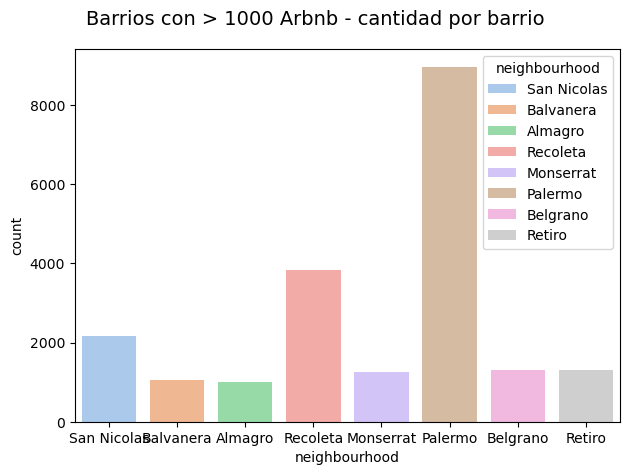

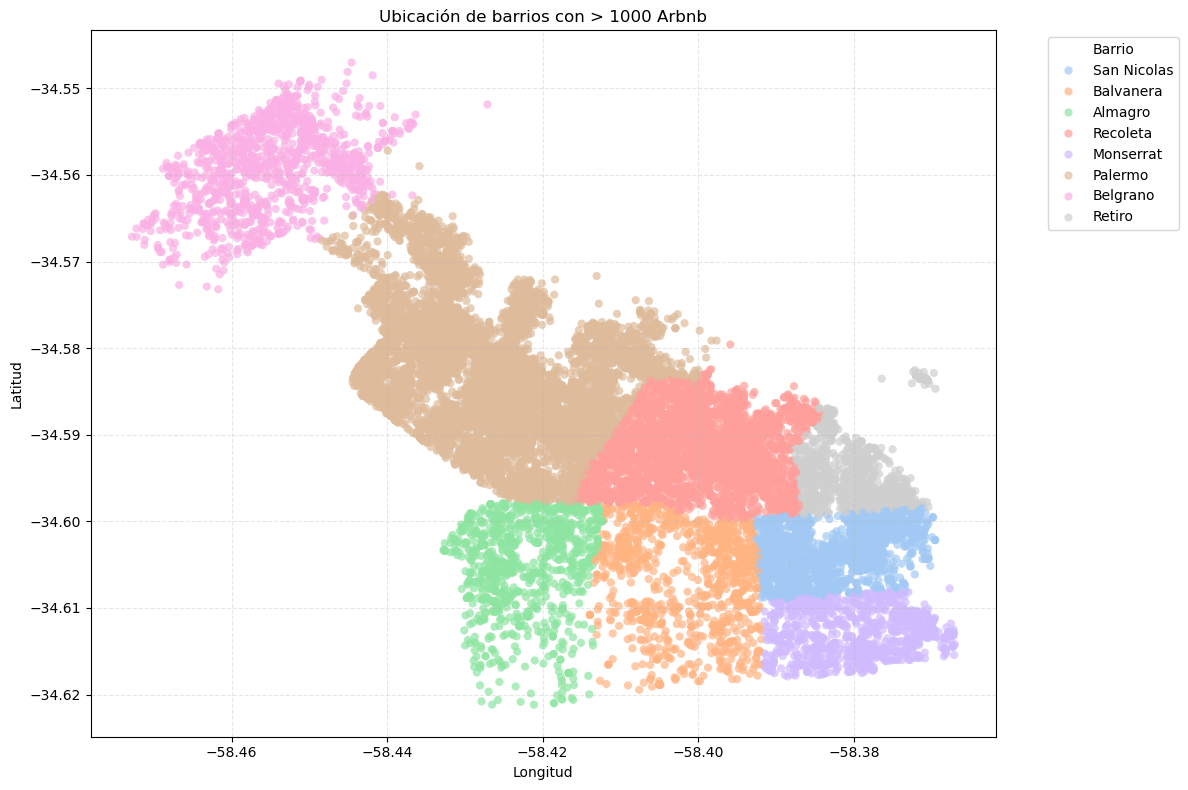

In [257]:
sns.countplot(x="neighbourhood", data=top_barrios_df, hue="neighbourhood", palette='pastel', legend='brief')

plt.suptitle('Barrios con > 1000 Arbnb - cantidad por barrio', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=top_barrios_df, x='longitude', y='latitude', hue='neighbourhood', palette='pastel', alpha=0.7, s=35, edgecolor='none')
plt.title('Ubicación de barrios con > 1000 Arbnb')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barrio')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Grafico de disponibilidad

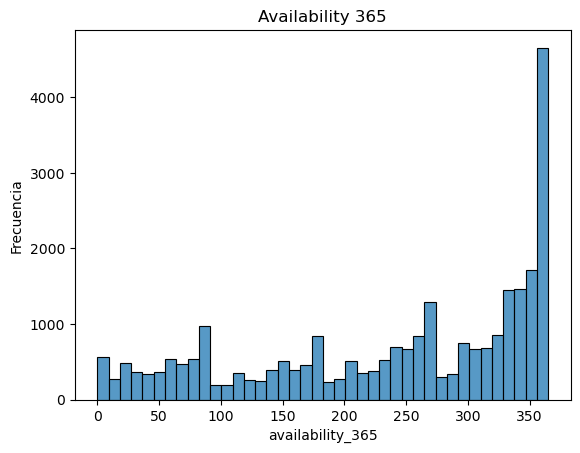

In [258]:
sns.histplot(df["availability_365"].dropna(), bins=40)
plt.title("Availability 365")
plt.xlabel("availability_365")
plt.ylabel("Frecuencia")
plt.show()

Cantidad de reviews vs disponibilidad

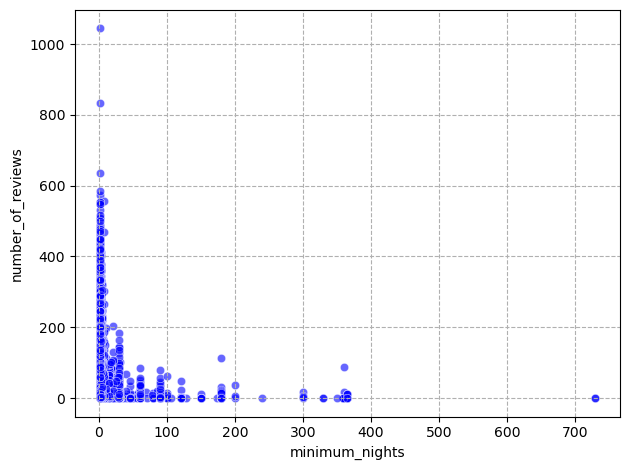

In [259]:

sns.scatterplot(data=df, x='minimum_nights', y='number_of_reviews', color='b',alpha=0.6)
	
plt.grid(ls='--')
plt.title('')
plt.tight_layout()
plt.show()

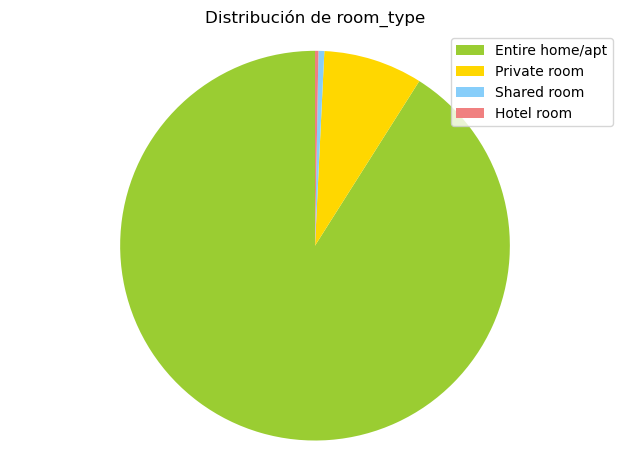

In [260]:
#plot_pie(Airbnb_df, "room_type")
labels = df["room_type"].value_counts().index
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral']
patches, texts = plt.pie(df["room_type"].value_counts(), colors=colors, startangle=90)
plt.title(f'Distribución de room_type')
plt.legend(patches, labels, loc="best")
# Set aspect ratio to be equal so that pie is drawn as a circle.
plt.axis('equal')
plt.tight_layout()
plt.show()

Observamos en este grafico de torta que casi la mayoria de la oferta son home/aprt o en mucha menor cantidad habitaciones privada, y muy infima la oferta de habitaciones de hotel o habitacions compartidas

Ralizamos una matriz de correlacion entre las variables numericas

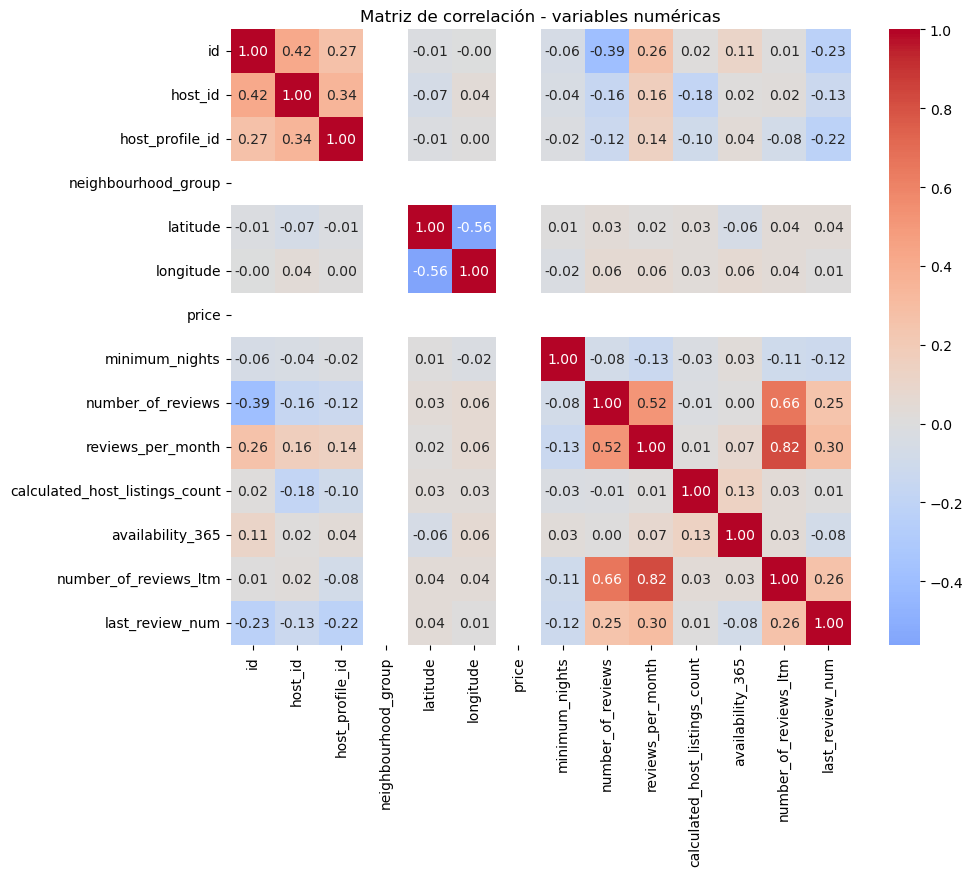

In [261]:
numerical_cols = df.select_dtypes(include=['number']).columns
corr = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

Se observa la matriz de correlacion de kendall entre las variables numericas, no se observa ninguna correlacion muy fuerte entre ningunas de las variables. Solo hay alguna correlaciones entre el numero de reviws y el numero de reviews ltm o el ultimo mes de reviews

Realizamos un boxplot de cada una de las variables numericas. En la mayoria de los casos, si se hace con el total de los datos queda totalmente dificil de interpretar, solamente eliminando el 1% y aqueda un grafico mucho mas aceptable para interpretarlo

In [264]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,last_review_num
0,42610838,"Puerto Madero a 3 cuadras, centro, bello , tea...",224049389,1469188629918707060,Gabriela,NaN,San Nicolas,-34.599976,-58.374195,Entire home/apt,NaN,7.0,0,NaT,NaN,2,244,0,NaN,-9223372036854775808
1,1305876403852901802,Apart estudio en Microcentro,25649070,1465347917068117288,Federico,NaN,San Nicolas,-34.600382,-58.372692,Entire home/apt,NaN,2.0,1,2025-01-18,0.08,1,307,0,NaN,1737158400000000
2,1542233033640525302,"Departamento en Buenos Aires, abasto shopping",153014015,1468500000533080859,Marco,NaN,Balvanera,-34.603295,-58.409527,Entire home/apt,NaN,7.0,0,NaT,NaN,1,326,0,NaN,-9223372036854775808
3,1004530078359434134,Departamento en Recoleta,1409800,1462517876404348407,Marian,NaN,Balvanera,-34.599230,-58.407060,Entire home/apt,NaN,1.0,22,2025-12-07,0.80,39,365,3,NaN,1765065600000000
4,800145927121871422,Coqueto para 4 personas,467965425,1470109782901816721,Maria Del Carmen,NaN,Almagro,-34.599767,-58.426499,Entire home/apt,NaN,1.0,0,NaT,NaN,2,365,0,NaN,-9223372036854775808


Vemos el top 10 de usuario que mayor cantidad de publicaciones tienen

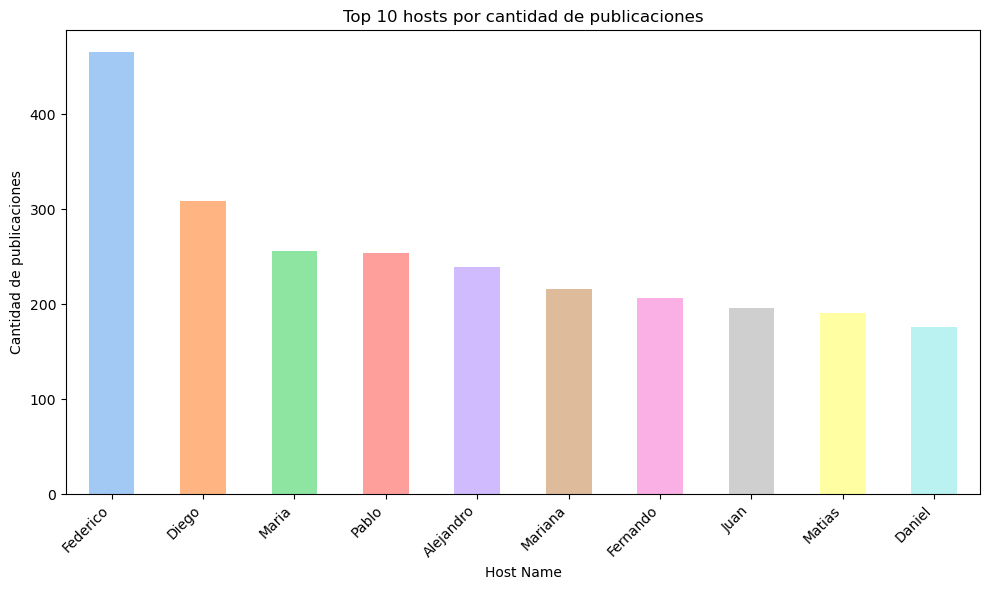

In [270]:
usuario_max = df.groupby('host_name')['id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
usuario_max.plot(kind='bar', color=sns.color_palette('pastel', len(usuario_max)))
plt.title('Top 10 hosts por cantidad de publicaciones')
plt.xlabel('Host Name')
plt.ylabel('Cantidad de publicaciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Vemos los barrios con mayor cantidad de reviews el ultimo ano

C:\Users\Gonzalo Rodriguez\AppData\Local\Temp\ipykernel_21404\1633799684.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x='neighbourhood', y='count', palette='pastel', order=top['neighbourhood'])


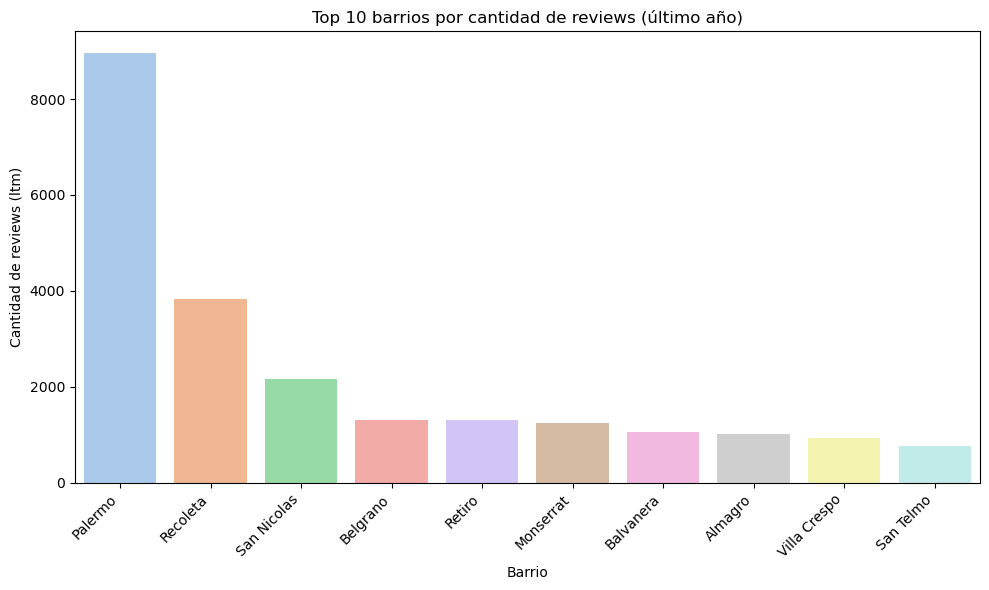

In [274]:
barrios_max = df.groupby("neighbourhood")["number_of_reviews_ltm"].count().sort_values(ascending=False).head(10)
top = barrios_max.reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=top, x='neighbourhood', y='count', palette='pastel', order=top['neighbourhood'])
plt.title('Top 10 barrios por cantidad de reviews (último año)')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de reviews (ltm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()